# **Imports**


In [1]:
from langgraph.graph import StateGraph, START , END
from typing import TypedDict,List ,Optional,Annotated,List,Union
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from  dotenv import load_dotenv
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.output_parsers import PydanticOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
import operator
load_dotenv()

e:\Ai_Carrer_Coach\carrercoach\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

# **JD Analysis**

# **Pydantic for JD Analysis**

In [2]:
# Structured Output For Jd Analysis
from pydantic import BaseModel,Field

class JDAnalysis(BaseModel):
    role: str = Field(description="Job role or title")
    experience_level: str = Field(description="Junior / Mid / Senior / Lead")
    required_skills: List[str] = Field(description="Core technical or professional skills")
    responsibilities: List[str] = Field(description="Main responsibilities of the role")


# **Pydantic for Interview Question Generator Node**

In [3]:
#Pydantic class for the second node
class InterviewQuestions(BaseModel):
    questions: List[str] = Field(description="A list of 3 tailored interview questions")

# **Pydantic for feedback Node**

In [4]:
class InterviewFeedback(BaseModel):
    score: int = Field(description="Overall score from 0 to 100")
    strengths: List[str] = Field(description="What the candidate did well")
    improvements: List[str] = Field(description="Specific areas to improve")
    verdict: str = Field(description="Final 'Hire' or 'No Hire' recommendation")

# **LLM**

In [5]:
# LLM define
llm = ChatGroq(model="llama-3.3-70b-versatile")
jd_llm = llm.with_structured_output(JDAnalysis)
questions_llm = llm.with_structured_output(InterviewQuestions)
feedback_llm = llm.with_structured_output(InterviewFeedback)

# **Graph State**

In [ ]:
# Define State
class JDState(TypedDict):
    job_description: str
    role: str
    experience_level: str
    required_skills: List[str]
    responsibilities: List[str]
    questions: List[str]
    # New field to track progress
    current_question_index: int
    last_audio_file: Optional[str]  # AI question audio
    last_answer_file: Optional[str] # User answer audio
    user_answers: Annotated[List[str], operator.add]       # To store transcriptions
    feedback: Optional[dict]

# **Graph Nodes**

# **JD Analyzer Node**

In [7]:
# JD Analyzer Node
def jd_analyzer_node(state: JDState)-> JDState:

    jd_prompt = ChatPromptTemplate.from_messages([
    ("system",
           "You are an expert technical recruiter. Your task is to extract information "
            "EXACTLY as defined in the provided schema. Do not include any extra fields "
            "like 'company' or 'location' that are not in the schema."
    ),
    
    ("human",
     "Analyze the following job description and extract key information:\n\n{job_description}")
    ])

    chain = jd_prompt | jd_llm  

    result = chain.invoke({ "job_description": state["job_description"]})

    return {
        "role": result.role,
        "experience_level": result.experience_level,
        "required_skills": result.required_skills,
        "responsibilities": result.responsibilities
    }


# **Interview Question Node**

In [8]:
# Interview Qustion Generator Node
def interview_question_node(state: JDState) -> JDState:
        
    prompt1 = ChatPromptTemplate.from_messages([
        ("system", "You are an expert Technical interviewer. Generate exactly 3 technical interview questions according to experince , Role and Required Skills."),
        ("human", "Generate questions for a {role} focusing on these skills: {required_skills} having experinece {experience_level}")
    ])

    chain1 = prompt1 | questions_llm

    result1 = chain1.invoke({"role": state["role"],
                            "required_skills": state["required_skills"],
                            "experience_level": state["experience_level"]})
    
    return {"questions": result1.questions}

# **Speak Question Node**

In [ ]:
# Speak Question Node
from elevenlabs.client import ElevenLabs
from elevenlabs.play import play
import os
from datetime import datetime


# Client automatically looks for ELEVENLABS_API_KEY in your .env
el_client = ElevenLabs()

def speak_question_node(state: JDState) -> JDState:
    # Safely get index and questions with defaults
    idx = state.get("current_question_index", 0)
    questions = state.get("questions", [])
    
    if questions and idx < len(questions):
        current_q = questions[idx]
        print(f"\n🤖 AI Coach: {current_q}")
        
        # Audio generation logic...
        # --- NEW SDK SYNTAX ---
        audio = el_client.text_to_speech.convert(
            text=current_q,
            voice_id="okVufheuRpZQnEhP61M4", 
            model_id="eleven_multilingual_v2",
            output_format="mp3_44100_128"
        )

        # Convert iterator → bytes
    audio_bytes = b"".join(audio)

    # Create audio directory if not exists
    os.makedirs("audio_outputs", exist_ok=True)

    # Unique filename per question
    filename = f"audio_outputs/question_{idx}_{datetime.now().strftime('%H%M%S')}.mp3"

    # Save to file
    with open(filename, "wb") as f:
        f.write(audio_bytes)

    print(f"🔊 Audio saved at: {filename}")

    # Save path in state 
    state["last_audio_file"] = filename
    state["current_question_index"] = idx + 1
    
        
    return state



In [10]:
# Router Function
def should_continue_after_answer(state: JDState):
    if state["current_question_index"] < len(state["questions"]):
        return "speak_question_node"
    return "feedback_coach_node"

# **Record Answer Node**

In [ ]:
# Record Answer Node
import speech_recognition as sr
import os
from datetime import datetime

def record_answer_node(state: JDState) -> JDState:
    recognizer = sr.Recognizer()

    with sr.Microphone() as source:
        print("\n🎤 Press ENTER and start answering...")
        input()
        print("🎙️ Listening... Speak freely.")

        recognizer.adjust_for_ambient_noise(source, duration=0.5)
        audio = recognizer.listen(source)

        print(" Recording finished.")

    os.makedirs("answer_audio", exist_ok=True)

    idx = state["current_question_index"] - 1
    filename = f"answer_audio/answer_{idx}_{datetime.now().strftime('%H%M%S')}.wav"

    with open(filename, "wb") as f:
        f.write(audio.get_wav_data())

    state["last_answer_file"] = filename
    return state


# **Transcribe Answer Node**

In [ ]:
# Transcribe Node
import whisper
whisper_model = whisper.load_model("base")

def transcribe_answer_node(state: JDState) -> JDState:
    audio_path = state["last_answer_file"]

    print(" Transcribing answer...")
    result = whisper_model.transcribe(audio_path)

    text = result["text"].strip()

    print(f"🗣️ You said: {text}")

    return {
        "user_answers": [text]
    }


# **Feedback Node**

In [13]:
# Feedback Node
def feedback_coach_node(state: JDState) -> JDState:
    prompt = ChatPromptTemplate.from_messages([
        ("system",
            "You are a Senior Hiring Manager and Interview Coach. "
            "Evaluate the candidate's interview answers strictly and fairly. "
            "Give a numeric score, clear strengths, improvements, and a final verdict."
        ),
        ("human",
           """
           Role: {role}
           Experience Level: {experience_level}
           Interview Questions:{questions}
        Candidate Answers:{user_answers}
        Provide your evaluation strictly in the defined schema.
        """
        )
    ])

    chain = prompt | feedback_llm

    result = chain.invoke({
        "role": state["role"],
        "experience_level": state["experience_level"],
        "questions": state["questions"],
        "user_answers": state["user_answers"]
    })

    print(" ===== INTERVIEW FEEDBACK =====")
    print(f"Score: {result.score}/100")
    print("Strengths:")
    print("Improvements:")
    print(f"Final Verdict: {result.verdict}")
    print("================================\n")

    # Store feedback in state 
    return {
        "feedback": result.model_dump()
    }

# **Graph Workflow**

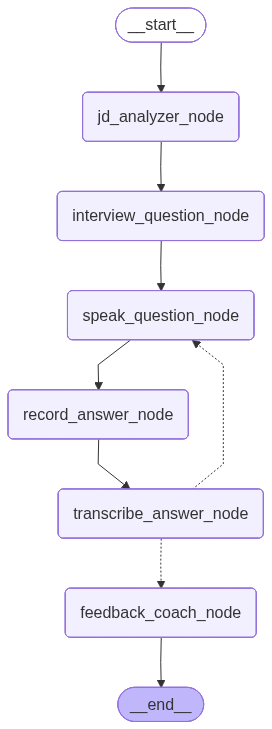

In [ ]:
# Graph Define
graph = StateGraph(JDState)

# Nodes
graph.add_node("jd_analyzer_node" , jd_analyzer_node)
graph.add_node("interview_question_node",interview_question_node)
graph.add_node("speak_question_node",speak_question_node)
graph.add_node("record_answer_node",record_answer_node)
graph.add_node("transcribe_answer_node",transcribe_answer_node)
graph.add_node("feedback_coach_node", feedback_coach_node)

# Edges
graph.add_edge(START,'jd_analyzer_node')
graph.add_edge('jd_analyzer_node','interview_question_node')
graph.add_edge('interview_question_node','speak_question_node')

# ---- Per-question flow ----
graph.add_edge("speak_question_node", "record_answer_node")
graph.add_edge("record_answer_node", "transcribe_answer_node")

# ---- Loop / Exit decision ----
graph.add_conditional_edges(
    "transcribe_answer_node",
    should_continue_after_answer,
    {
        "speak_question_node": "speak_question_node",  # next question
        "feedback_coach_node": "feedback_coach_node"                                # final feedback
    }
)

# ---- End ----
graph.add_edge("feedback_coach_node", END)

workflow =  graph.compile()
workflow


# **Testing Workflow**

In [15]:
intial_state={
    'job_description':""" ob Description: Junior Machine Learning Engineer
Location: Remote / Pune, India

Experience: 0–2 Years

Type: Full-time

Role Summary
We are looking for a motivated Junior Machine Learning Engineer to join our AI development team. In this role, you will help build, deploy, and maintain machine learning models that solve real-world business problems. You will work closely with Data Scientists and Software Engineers to transition models from research experiments into production-ready services.

Key Responsibilities
Model Implementation: Assist in building and training ML models using frameworks like PyTorch or TensorFlow.

Data Engineering: Clean, preprocess, and perform exploratory data analysis (EDA) on large datasets to ensure high-quality model inputs.

Deployment: Help containerize ML models using Docker and deploy them via API endpoints (FastAPI/Flask).

Monitoring: Monitor model performance in production and assist in retraining cycles.

Collaboration: Work with cross-functional teams to integrate AI features into existing web applications.

Required Technical Skills
Programming: Strong proficiency in Python (NumPy, Pandas, Scikit-learn).

ML Frameworks: Familiarity with PyTorch, TensorFlow, or Keras.

Mathematics: Solid understanding of Linear Algebra, Calculus, and Statistics.

Tools: Experience with Git for version control and basic knowledge of SQL.

Cloud Basics: Familiarity with at least one cloud platform (AWS, Azure, or GCP).

Preferred Qualifications
A Bachelor’s or Master’s degree in Computer Science, Data Science, or a related field.

Knowledge of MLOps tools like MLflow or DVC.

Experience with Large Language Models (LLMs) or Generative AI APIs."""}
result = workflow.invoke(intial_state)
result





🤖 AI Coach: 1. How would you implement a simple neural network using PyTorch to classify handwritten digits, and what are the key considerations for choosing the optimal hyperparameters?
🔊 Audio saved at: audio_outputs/question_0_165302.mp3

🎤 Press ENTER and start answering...
🎙️ Listening... Speak freely.
✅ Recording finished.
📝 Transcribing answer...


e:\Ai_Carrer_Coach\carrercoach\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


🗣️ You said: I really useinspire

🤖 AI Coach: 2. Write a Python function to perform linear regression using scikit-learn, and explain how you would evaluate the model's performance using metrics such as mean squared error and R-squared?
🔊 Audio saved at: audio_outputs/question_1_165403.mp3

🎤 Press ENTER and start answering...
🎙️ Listening... Speak freely.
✅ Recording finished.
📝 Transcribing answer...
🗣️ You said: I did it. No, I'll try it.

🤖 AI Coach: 3. Suppose you are working on a project that involves deploying a machine learning model on a cloud platform, and you need to version control your code using Git and store data in a SQL database - describe your approach to setting up the project infrastructure and collaborating with team members.
🔊 Audio saved at: audio_outputs/question_2_165419.mp3

🎤 Press ENTER and start answering...
🎙️ Listening... Speak freely.
✅ Recording finished.
📝 Transcribing answer...
🗣️ You said: a
 ===== INTERVIEW FEEDBACK =====
Score: 0/100
Strengths:
Imp

{'job_description': ' ob Description: Junior Machine Learning Engineer\nLocation: Remote / Pune, India\n\nExperience: 0–2 Years\n\nType: Full-time\n\nRole Summary\nWe are looking for a motivated Junior Machine Learning Engineer to join our AI development team. In this role, you will help build, deploy, and maintain machine learning models that solve real-world business problems. You will work closely with Data Scientists and Software Engineers to transition models from research experiments into production-ready services.\n\nKey Responsibilities\nModel Implementation: Assist in building and training ML models using frameworks like PyTorch or TensorFlow.\n\nData Engineering: Clean, preprocess, and perform exploratory data analysis (EDA) on large datasets to ensure high-quality model inputs.\n\nDeployment: Help containerize ML models using Docker and deploy them via API endpoints (FastAPI/Flask).\n\nMonitoring: Monitor model performance in production and assist in retraining cycles.\n\nCo